In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 315,990
download_chandra_obsid 315,990


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1947.9 kb/s
  oif      fits       25 Kb  ####################          < 1 s  4051.9 kb/s
  vv       pdf        43 Kb  ####################          < 1 s  5364.5 kb/s
  cntr_img fits      258 Kb  ####################          < 1 s  15875.8 kb/s
  cntr_img jpg       656 Kb  ####################          < 1 s  24248.4 kb/s
  evt2     fits       23 Mb  ####################          < 1 s  76148.0 kb/s
  full_img fits       79 Kb  ####################          < 1 s  8898.9 kb/s
  full_img jpg        48 Kb  ####################          < 1 s  6275.8 kb/s
  src2     fits       22 Kb  ####################          < 1 s  3146.0 kb/s
  src_img  jpg        49 Kb  ####################          < 1 s  6402.6 kb/s
  bpix     fits       10 Kb  ####################          <

In [3]:
/bin/rm -rf repro
chandra_repro 315,990 ./repro 



Processing input directory '/data/sdsreg/thread_output/CIAO4.9/eff2evt/315'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.9): WARNING: problem reading ctifile, cti adjustment will not be applied. Changing apply_cti=yes to apply_cti=no.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/eff2evt/repro/acisf00315_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...

Cleaning up intermediate files

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/eff2evt/repro


Processing input d

In [4]:
 dmcopy "repro/acisf00315_repro_evt2.fits[energy=300:7000][ccd_id=7]" acis_315_filt7.fits clob+

In [5]:
eff2evt acis_315_filt7.fits acis_315_flux7.fits clob+

In [6]:
dmlist acis_315_flux7.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block EVENTS
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range            Null
   1   time                 s            Real8          60413209.3141160011: 60489714.2918820009 -          S/C TT corresponding to mid-exposure
   2   expno                             Int4           0:2147483647         -          Exposure number of CCD frame containing event
   3   ccd_id                            Int2           0:9                  -          CCD reporting event
   4   node_id                           Int2           0:3                  -          CCD serial readout amplifier node
   5   chip(chipx,chipy)    pixel        Int2           1:1024               -          Chip coords
   6   tdet(tdetx,tdety)    pixel        Int2           1:8192               9999       ACIS tiled detector coordin

## Photon flux

In [7]:
dmtcalc acis_315_flux7.fits acis_315_pflux7.fits \
      expression="pflux=1/(QE*EA*DACORR*LIVETIME)" cl+

In [8]:
dmlist "acis_315_pflux7.fits[cols pflux]" data row=1:20

 
--------------------------------------------------------------------------------
Data for Table Block EVENTS
--------------------------------------------------------------------------------
 
ROW    PFLUX
 
     1      3.740081191E-08
     2      2.233363209E-08
     3      3.048609988E-08
     4      2.285275182E-08
     5      1.081693592E-07
     6      4.842872243E-08
     7      2.028159524E-08
     8      1.105594801E-07
     9      3.505903713E-08
    10      3.594507287E-08
    11      1.021800245E-07
    12      2.114176812E-08
    13      4.105936067E-08
    14      3.612249578E-08
    15      2.373250668E-08
    16      8.317230915E-08
    17       2.37469245E-08
    18      7.097738415E-08
    19      2.517802557E-08
    20      2.359079949E-08


## HRC Data

In [9]:
eff2evt repro/hrcf00990_repro_evt2.fits hrc_990_flux.fits energy=1.1 clob+

In [10]:
dmlist hrc_990_flux.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block EVENTS
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   time                 s            Real8          97387353.0922120064: 97390363.0048280060 Time tag (TT)
   2   chip(chipx,chipy)    pixel        Int2           1:4096               Chip coords
   3   tdet(tdetx,tdety)    pixel        Int4           1:4096               Tdet coords
   4   det(detx,dety)       pixel        Real4          0.50:    65536.50    Det coords
   5   sky(x,y)             pixel        Real4          0.50:    65536.50    Sky coords
   6   pha                  chan         Int2           0:255                Pulse height
   7   pi                   chan         Int2           0:1023               Pulse Invariant
   8   chip_id                           Int2           1:3                  Chip ID
   9   

### Photon Flux

In [11]:
dmtcalc hrc_990_flux.fits hrc_990_pflux.fits \
  expression="pflux=1/(QE*EA*LIVETIME)" cl+

In [12]:
dmlist "hrc_990_pflux.fits[cols pflux]" data row=1:10 

 
--------------------------------------------------------------------------------
Data for Table Block EVENTS
--------------------------------------------------------------------------------
 
ROW    PFLUX
 
     1      2.299885127E-06
     2      2.302278046E-06
     3      2.301929413E-06
     4      2.301530595E-06
     5      2.300490953E-06
     6      2.333012824E-06
     7      2.301969863E-06
     8       3.86853127E-06
     9      2.312692695E-06
    10      2.300217868E-06


## Examine Output

In [13]:
dmstat "acis_315_flux7.fits[sky=circle(4191.5,3857.5,158.74268)][cols flux]"

FLUX[ergs/cm**2/s]
    min:	2.9154089877e-17 	      @:	6670 
    max:	1.6357235357e-15 	      @:	8225 
   mean:	8.393429619e-17 
  sigma:	1.5079479477e-16 
    sum:	2.5633534057e-12 
   good:	30540 
   null:	0 



In [22]:
dmstat "acis_315_flux7.fits[sky=circle(4191.5,3857.5,158.74268)][cols flux]" \
      verbose=0

In [14]:
pget dmstat out_sum

2.5633534057e-12


In [15]:
pget dmstat out_max

1.6357235357e-15


### Create image

In [16]:
dmcopy "acis_315_flux7.fits[sky=circle(4191.5,3857.5,158.74268)][bin x,y;flux]" acis_315_flux7.img clob+

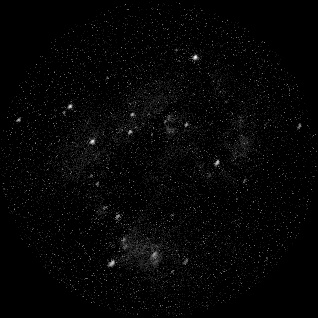

In [17]:
dmimg2jpg infile=acis_315_flux7.img outfile=acis_315_flux7.jpg scalefun=log mode=h clob+
display < acis_315_flux7.jpg

In [18]:
dmstat acis_315_flux7.img cen-

EVENTS_IMAGE[ergs/cm**2/s]
    min:	0 	      @:	( 4179.25732 3699.25732 )
    max:	5.2172011828e-14 	      @:	( 4228.25732 3959.25732 )
   mean:	3.2346347965e-17 
  sigma:	3.9783750991e-16 
    sum:	2.5603751731e-12 
   good:	79155 
   null:	21969 


In [19]:
dmstat acis_315_flux7.img cen- verbose=0

In [20]:
pget dmstat out_sum

2.5603751731e-12


In [21]:
pget dmstat out_max

5.2172011828e-14
